&emsp;Este notebook ajusta localmente um modelo de OCR de placas usando seu conjunto de dados, que deve conter o arquivo `dataset/plates/plates.csv` com as colunas `image_path` e `plate_text` e as imagens referenciadas em `dataset/plates/plate_imgs/`.

&emsp;Nesta etapa configuramos o ambiente definindo variaveis do TensorFlow e do Keras antes das importacoes, reduzindo logs e garantindo o backend correto.

In [129]:
%env TF_CPP_MIN_LOG_LEVEL=3
%env KERAS_BACKEND=tensorflow

env: TF_CPP_MIN_LOG_LEVEL=3
env: KERAS_BACKEND=tensorflow


&emsp;Nesta etapa carregamos o CSV de anotacoes e conferimos algumas linhas para validar caminhos e textos das placas antes de prosseguir.

In [ ]:
import pandas as pd

CSV_PATH = "ocr/dataset/plates/plates.csv"
IMG_DIR = "ocr/dataset/plates"

df = pd.read_csv(CSV_PATH)
print(f"Total samples: {len(df)}")
print(df.head(10))

Total samples: 206
               image_path plate_text
0  plate_imgs/plate_0.jpg    PYP5727
1  plate_imgs/plate_1.jpg    QUP8066
2  plate_imgs/plate_2.jpg    ELS7575
3  plate_imgs/plate_3.jpg    EJA9040
4  plate_imgs/plate_4.jpg    ELS7575
5  plate_imgs/plate_5.jpg    EHJ9C82
6  plate_imgs/plate_6.jpg    LUO1J10
7  plate_imgs/plate_7.jpg    KWE8269
8  plate_imgs/plate_8.jpg    KRF8219
9  plate_imgs/plate_9.jpg    KWE8269


&emsp;Aqui convertemos os caminhos das imagens para o formato esperado, copiamos os arquivos para a pasta de split e geramos os CSVs de treino e validacao.

In [ ]:
import shutil
import pandas as pd
from pathlib import Path
from sklearn.model_selection import train_test_split

CSV_PATH = "ocr/dataset/plates/plates.csv"
IMG_DIR = "ocr/dataset/plates"

df = pd.read_csv(CSV_PATH)

split_img_dir = Path("ocr/dataset/split/plate_imgs")
split_img_dir.mkdir(parents=True, exist_ok=True)

def copy_and_repath(image_path):
    src = Path(IMG_DIR) / image_path
    filename = Path(image_path).name
    dst = split_img_dir / filename
    shutil.copy2(src, dst)
    return f"plate_imgs/{filename}"

df["image_path"] = df["image_path"].apply(copy_and_repath)

missing = [p for p in df["image_path"] if not (Path("dataset/split") / p).exists()]
if missing:
    print(f"WARNING: {len(missing)} missing images")
else:
    print("All images copied ✓")

if len(df) >= 5:
    train_df, val_df = train_test_split(df, test_size=0.2, random_state=42)
else:
    train_df, val_df = df.copy(), df.copy()
    print("⚠️  Very few samples — using same data for train and validation.")

print(f"Train: {len(train_df)} | Val: {len(val_df)}")

train_df.to_csv("dataset/split/train_annotations.csv", index=False)
val_df.to_csv("dataset/split/val_annotations.csv", index=False)
print("Saved CSVs ✓")

All images copied ✓
Train: 164 | Val: 42
Saved CSVs ✓


&emsp;Nesta etapa validamos as anotacoes e imagens para garantir que nao ha arquivos corrompidos nem caracteres fora do conjunto permitido.

In [ ]:
!fast-plate-ocr validate-dataset \
    --annotations-file ocr/dataset/split/train_annotations.csv \
    --plate-config-file ocr/config/plate_config.yaml

⠋ ------------------------------------------------------- 0/164 Scanning images
  ----------------------------------------------------- 164/164 Scanning images


 Validation Summary 
┌──────────┬───────┐
│ Category │ Count │
├──────────┼───────┤
│ Errors   │     0 │
│ Warnings │     0 │
└──────────┴───────┘


I0000 00:00:1780000991.436398   16808 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1780000993.098386   16808 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [ ]:
!fast-plate-ocr validate-dataset \
    --annotations-file ocr/dataset/split/val_annotations.csv \
    --plate-config-file ocr/config/plate_config.yaml

⠋ -------------------------------------------------------- 0/42 Scanning images
  ------------------------------------------------------- 42/42 Scanning images


 Validation Summary 
┌──────────┬───────┐
│ Category │ Count │
├──────────┼───────┤
│ Errors   │     0 │
│ Warnings │     1 │
└──────────┴───────┘

                    Warnings                     
┌──────┬────────────────────────────────────────┐
│ Line │ Message                                │
├──────┼────────────────────────────────────────┤
│    - │ Character(s) not found in any plate: X │
└──────┴────────────────────────────────────────┘


I0000 00:00:1780000996.678274   24404 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1780000998.242473   24404 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


&emsp;Se a validacao apontar erros, exporte os CSVs corrigidos com `--export-fixed` e use os arquivos `_fixed.csv` nas etapas seguintes.

&emsp;Opcionalmente, visualize as augmentations para entender como as imagens serao transformadas durante o treinamento.

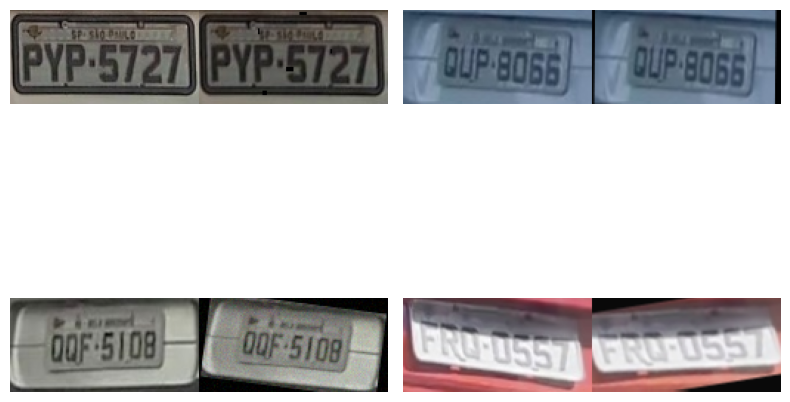

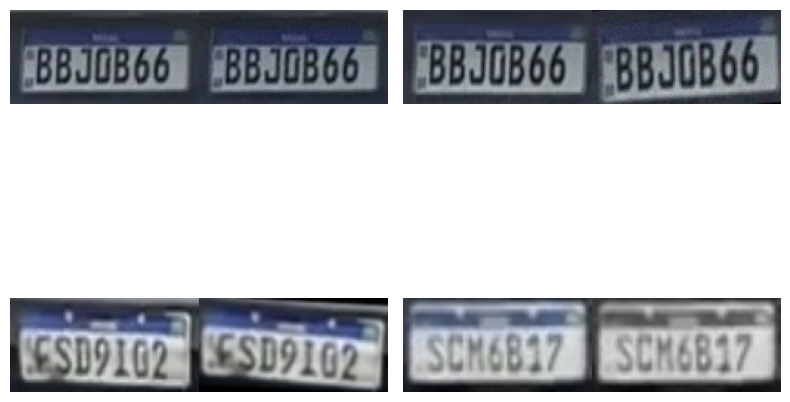

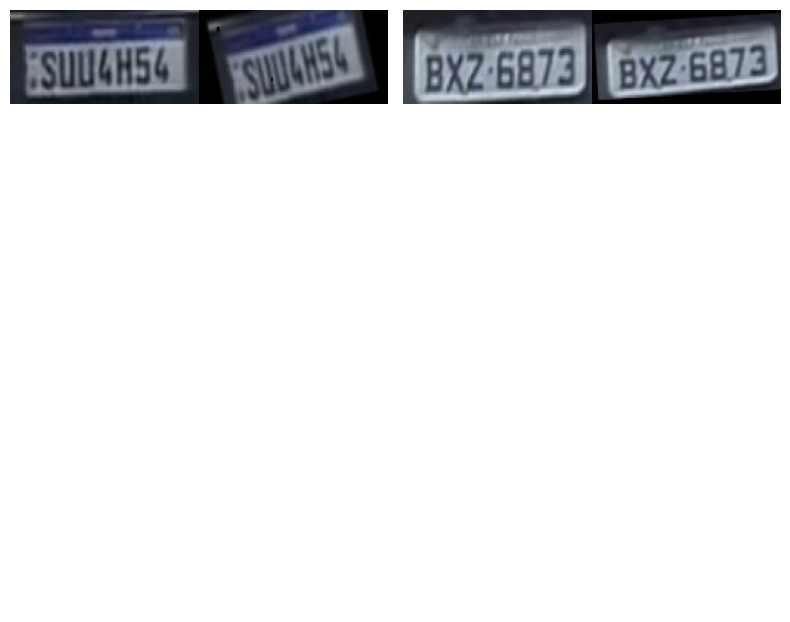

In [ ]:
%matplotlib inline
%run -m fast_plate_ocr.cli.visualize_augmentation -- \
    --img-dir ocr/dataset/plates/plate_imgs \
    --columns 2 \
    --rows 2 \
    --show-original \
    --num-images 10 \
    --plate-config-file ocr/config/plate_config.yaml

&emsp;Aqui iniciamos o fine-tuning com os CSVs de treino e validacao, ajustando `--epochs` e `--batch-size` conforme o tamanho do conjunto de dados.

In [ ]:
!fast-plate-ocr train \
    --model-config-file ocr/config/model_config.yaml \
    --plate-config-file ocr/config/plate_config.yaml \
    --annotations       ocr/dataset/split/train_annotations.csv \
    --val-annotations   ocr/dataset/split/val_annotations.csv \
    --epochs 50 \
    --batch-size 8 \
    --output-dir ocr/modelos_treinados/ \
    --weights-path ocr/modelos/base_model.keras \
    --label-smoothing 0.0 \
    --weight-decay 0.0005 \
    --lr 0.0005

In [ ]:
!fast-plate-ocr valid \
  --model modelos_treinados/best.keras \
  --plate-config-file ocr/config/plate_config.yaml \
  --annotations dataset/split/val_annotations.csv 


 1/42 ━━━━━━━━━━━━━━━━━━━━ 1:05 2s/step - acc: 1.0000 - char_acc: 1.0000 - len_acc: 1.0000 - loss: 0.1355 - top3_acc: 1.0000
 4/42 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - acc: 1.0000 - char_acc: 1.0000 - len_acc: 1.0000 - loss: 0.1425 - top3_acc: 1.0000
 7/42 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - acc: 1.0000 - char_acc: 1.0000 - len_acc: 1.0000 - loss: 0.1443 - top3_acc: 1.0000
10/42 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - acc: 0.9900 - char_acc: 0.9980 - len_acc: 1.0000 - loss: 0.1748 - top3_acc: 0.9980
13/42 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - acc: 0.9730 - char_acc: 0.9946 - len_acc: 1.0000 - loss: 0.2259 - top3_acc: 0.9946
16/42 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - acc: 0.9655 - char_acc: 0.9931 - len_acc: 1.0000 - loss: 0.2504 - top3_acc: 0.9931
19/42 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - acc: 0.9622 - char_acc: 0.9924 - len_acc: 1.0000 - loss: 0.2623 - top3_acc: 0.9924
22/42 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - acc: 0.9608 - char_acc: 0.9922 - len_acc: 1.0000 - loss: 0.2675 - top3_acc: 0.9922

I0000 00:00:1780001024.403208   16312 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1780001025.991784   16312 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1780001027.849788   16312 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE3 SSE4.1 SSE4.2 AVX AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.

2026-05-28 17:43:48 - From C:\Users\anton\OneDrive\Documentos\GitHub\g01\notebook\venv\Lib\site-packages\keras

&emsp;Depois do treino, selecionamos o melhor checkpoint `.keras` e exportamos o modelo para ONNX para facilitar a inferencia.

In [ ]:
import glob

checkpoints = glob.glob("ocr/modelos_treinados/**/*.keras", recursive=True)
print("Found:", checkpoints)

acc_checkpoints = [p for p in checkpoints if "acc_" in p]

if acc_checkpoints:
    best_model = sorted(acc_checkpoints, key=lambda p: float(p.split("acc_")[-1].replace(".keras", "")))[-1]
else:
    best_checkpoints = [p for p in checkpoints if "best" in p]
    if best_checkpoints:
        best_model = best_checkpoints[0]
    else:
        best_model = checkpoints[0]

print(f"Using model: {best_model}")

Found: ['modelos_treinados\\best.keras', 'modelos_treinados\\last.keras']
Using model: modelos_treinados\best.keras


In [ ]:
!fast-plate-ocr export \
    --format onnx \
    --plate-config-file ocr/config/plate_config.yaml \
    --simplify \
    --model {best_model}

exported_onnx = best_model.replace(".keras", ".onnx")
print(f"Exported ONNX model: {exported_onnx}")

Exported ONNX model: modelos_treinados\best.onnx


I0000 00:00:1780001034.097696    2528 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1780001035.758786    2528 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1780001037.712800    2528 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE3 SSE4.1 SSE4.2 AVX AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.

2026-05-28 17:43:58 - From C:\Users\anton\OneDrive\Documentos\GitHub\g01\notebook\venv\Lib\site-packages\keras

&emsp;Nesta etapa executamos a inferencia em uma imagem de teste para verificar a previsao da placa.

Plate config declares regions but the loaded model has no 'region' output. Region predictions will be disabled.


Predicted plate: [PlatePrediction(plate='QUP8066', char_probs=None, region=None, region_prob=None)]


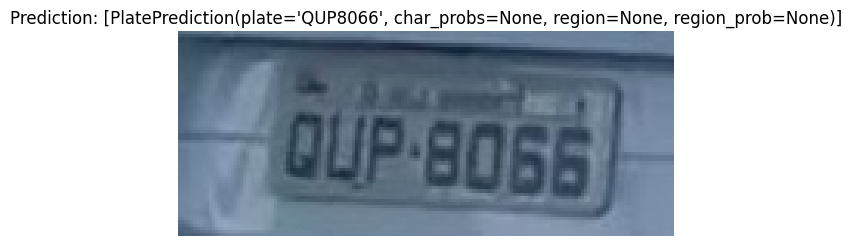

: 

In [ ]:
from fast_plate_ocr import LicensePlateRecognizer
import cv2
from matplotlib import pyplot as plt

recognizer = LicensePlateRecognizer(
    onnx_model_path=exported_onnx,
    plate_config_path="ocr/config/plate_config.yaml",
)

TEST_IMAGE = "dataset/plates/plate_imgs/plate_1.jpg"

img = cv2.imread(TEST_IMAGE)
result = recognizer.run(img)
print("Predicted plate:", result)

plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title(f"Prediction: {result}")
plt.axis("off")
plt.show()

In [ ]:
# Teste de integracao OCR -> API de vehicle lookup
from pathlib import Path
import sys
from dotenv import load_dotenv

repo_root = Path.cwd()
if not (repo_root / 'src').exists() and (repo_root.parent / 'src').exists():
    repo_root = repo_root.parent

load_dotenv(repo_root / '.env')

src_path = repo_root / 'src'
if str(src_path) not in sys.path:
    sys.path.append(str(src_path))

from services.vehicle_service import lookup_vehicle_by_plate

def extract_plate_text(prediction_result):
    if prediction_result is None:
        raise RuntimeError('OCR result is empty.')

    if isinstance(prediction_result, str):
        return prediction_result

    if isinstance(prediction_result, list):
        if len(prediction_result) == 0:
            raise RuntimeError('OCR result list is empty.')
        first_item = prediction_result[0]
        if hasattr(first_item, 'plate'):
            return first_item.plate
        if isinstance(first_item, dict) and 'plate' in first_item:
            return first_item['plate']
        return str(first_item)

    if hasattr(prediction_result, 'plate'):
        return prediction_result.plate

    return str(prediction_result)

plate_text = extract_plate_text(result)
print(f'Plate extracted from OCR: {plate_text}')

try:
    lookup_response = lookup_vehicle_by_plate(
        plate_text,
        extra_payload={
            'geolocation': {
                'latitude': -23.5505,
                'longitude': -46.6333,
            }
        },
    )
    print('Lookup response (vehicle found):')
    print(lookup_response)
except Exception as exc:
    error_text = str(exc)
    if 'status=404' in error_text and 'VehicleLookup::NotFound' in error_text:
        print('Lookup response (valid query, vehicle not found):')
        print(error_text)
    else:
        print('Lookup failed with technical error:')
        print(error_text)